In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print("Shape:", df.shape)
print("\n")
print(df['readmitted'].value_counts())

Shape: (101766, 50)


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


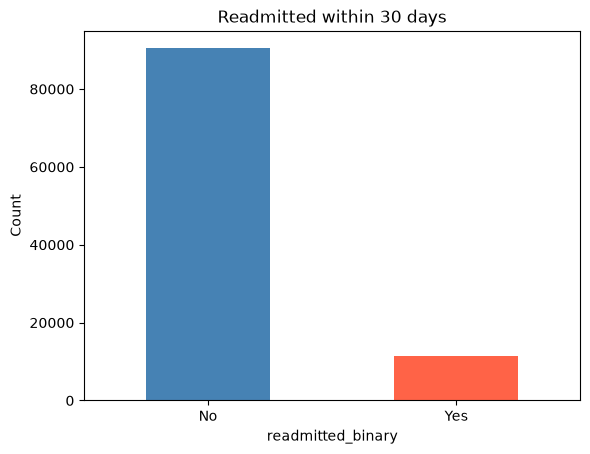

In [5]:
# แปลง readmitted เป็น binary
# <30 = 1 (readmitted เร็ว = ต้องการความสนใจ)
# NO และ >30 = 0

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_binary'].value_counts())

# plot ดูการกระจาย
df['readmitted_binary'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Readmitted within 30 days')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.ylabel('Count')
plt.show()

In [6]:
# เช็ค missing values
missing = df.isin(['?']).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [7]:
# Drop columns ที่ missing เยอะเกินไป
df = df.drop(columns=['weight', 'medical_specialty', 'payer_code'])

# แทนที่ ? ด้วย Unknown ใน race
df['race'] = df['race'].replace('?', 'Unknown')

# Drop แถวที่ diag missing
df = df.dropna(subset=['diag_1', 'diag_2', 'diag_3'])
df = df[~df['diag_1'].isin(['?'])]
df = df[~df['diag_2'].isin(['?'])]
df = df[~df['diag_3'].isin(['?'])]

print("Shape หลัง clean:", df.shape)
print("Missing values เหลือ:")
print(df.isin(['?']).sum().sum())

Shape หลัง clean: (100244, 48)
Missing values เหลือ:
0


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop columns ที่ไม่จำเป็น
df = df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])

# Encode categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# แยก X และ y
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80195, 44)
Test size: (20049, 44)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ผลลัพธ์
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17814
           1       0.57      0.01      0.02      2235

    accuracy                           0.89     20049
   macro avg       0.73      0.50      0.48     20049
weighted avg       0.85      0.89      0.84     20049

ROC-AUC Score: 0.6376


In [11]:
# เพิ่ม class_weight='balanced' เพื่อแก้ class imbalance
model2 = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'
)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
y_prob2 = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred2))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob2), 4))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     17814
           1       0.39      0.05      0.09      2235

    accuracy                           0.89     20049
   macro avg       0.64      0.52      0.51     20049
weighted avg       0.84      0.89      0.84     20049

ROC-AUC Score: 0.6496


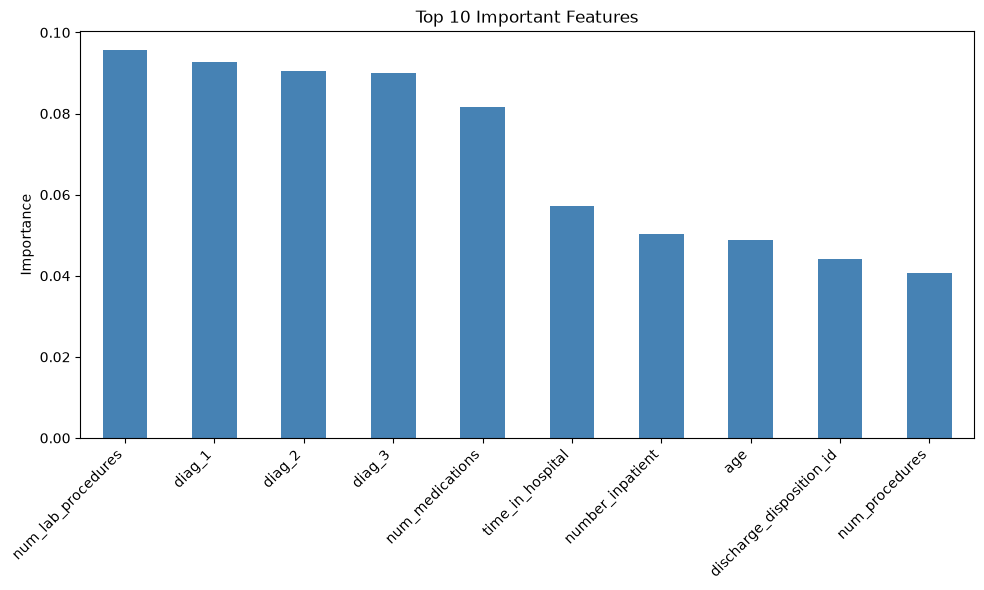

num_lab_procedures          0.095587
diag_1                      0.092754
diag_2                      0.090439
diag_3                      0.089926
num_medications             0.081689
time_in_hospital            0.057253
number_inpatient            0.050334
age                         0.048870
discharge_disposition_id    0.044105
num_procedures              0.040700
dtype: float64


In [12]:
# Feature Importance
feat_imp = pd.Series(
    model2.feature_importances_, 
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp)

In [13]:
import joblib

# Save model
joblib.dump(model2, 'model.pkl')
joblib.dump(list(X.columns), 'features.pkl')
print("Model saved!")

Model saved!
